In [1]:
import subprocess
subprocess.run(["pip", "install", "textblob", "wordcloud", "nltk"])

CompletedProcess(args=['pip', 'install', 'textblob', 'wordcloud', 'nltk'], returncode=0)

In [2]:
import textblob
import wordcloud
print("✅ Libraries ready!")

✅ Libraries ready!


In [3]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Path to dataset files:", path)

100%|██████████| 242M/242M [00:56<00:00, 4.51MB/s] 

Extracting files...


Path to dataset files: C:\Users\celin\.cache\kagglehub\datasets\snap\amazon-fine-food-reviews\versions\2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Load dataset
path = r"C:\Users\celin\.cache\kagglehub\datasets\snap\amazon-fine-food-reviews\versions\2\Reviews.csv"
df = pd.read_csv(path)

print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

✅ Dataset loaded!
Shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
# ── Use sample of 5000 for speed ──────────────────────────
df_sample = df[['Score', 'Summary', 'Text']].dropna().sample(5000, random_state=42)

# ── Get sentiment using TextBlob ───────────────────────────
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

print("Running sentiment analysis... please wait!")
df_sample['Sentiment'] = df_sample['Text'].apply(get_sentiment)
df_sample['Polarity'] = df_sample['Text'].apply(get_polarity)

print(f"✅ Sentiment analysis complete!")
print(f"\nSentiment breakdown:")
print(df_sample['Sentiment'].value_counts())
print(f"\nAverage polarity: {df_sample['Polarity'].mean():.2f}")

Running sentiment analysis... please wait!
✅ Sentiment analysis complete!

Sentiment breakdown:
Sentiment
Positive    4455
Negative     470
Neutral       75
Name: count, dtype: int64

Average polarity: 0.24


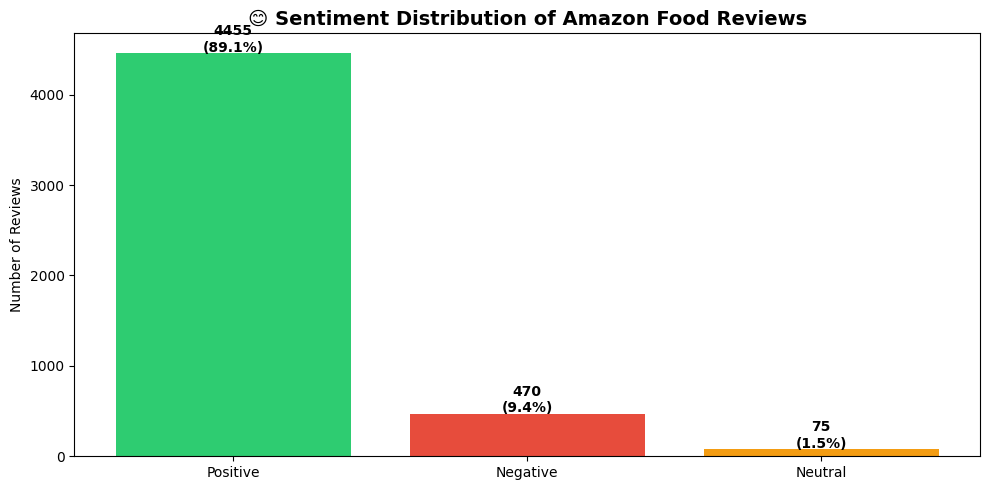

✅ Chart 1 saved!


In [6]:
# ── Chart 1: Sentiment Distribution ───────────────────────
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#e74c3c', '#f39c12']
sentiment_counts = df_sample['Sentiment'].value_counts()
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title('😊 Sentiment Distribution of Amazon Food Reviews', 
          fontsize=14, fontweight='bold')
plt.ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 20, f'{v}\n({v/len(df_sample)*100:.1f}%)', 
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

<Figure size 1000x500 with 0 Axes>

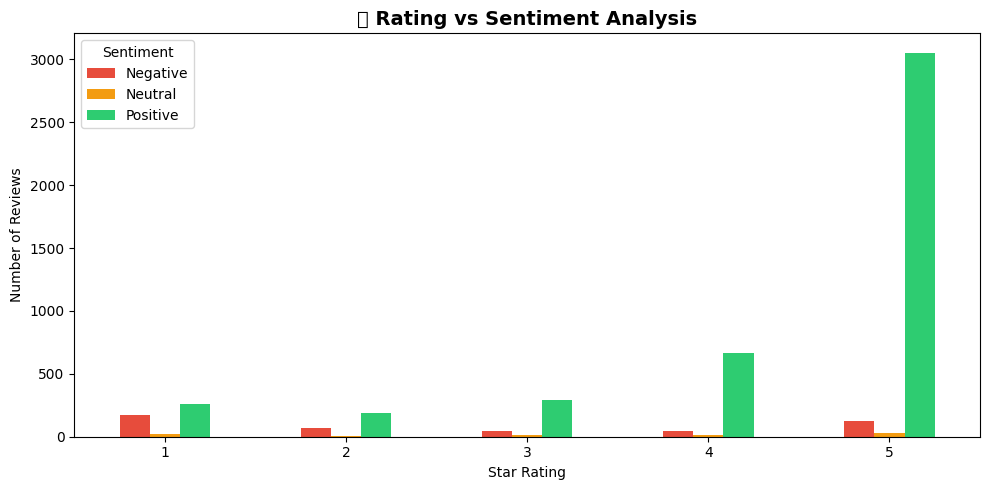

✅ Chart 2 saved!


In [7]:
# ── Chart 2: Rating vs Sentiment ──────────────────────────
plt.figure(figsize=(10, 5))
sentiment_by_rating = df_sample.groupby(['Score', 'Sentiment']).size().unstack(fill_value=0)
sentiment_by_rating.plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'], 
                          figsize=(10, 5))
plt.title('⭐ Rating vs Sentiment Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('rating_vs_sentiment.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

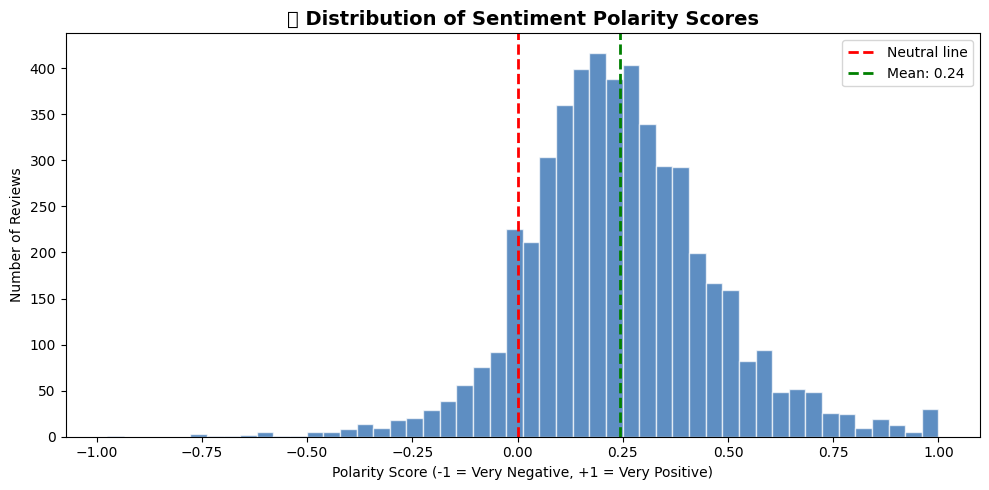

✅ Chart 3 saved!


In [8]:
# ── Chart 3: Polarity Distribution ────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df_sample['Polarity'], bins=50, color='#1a5fa8', alpha=0.7, edgecolor='white')
plt.axvline(x=0, color='red', linewidth=2, linestyle='--', label='Neutral line')
plt.axvline(x=df_sample['Polarity'].mean(), color='green', 
            linewidth=2, linestyle='--', label=f'Mean: {df_sample["Polarity"].mean():.2f}')
plt.title('📊 Distribution of Sentiment Polarity Scores', 
          fontsize=14, fontweight='bold')
plt.xlabel('Polarity Score (-1 = Very Negative, +1 = Very Positive)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('polarity_distribution.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

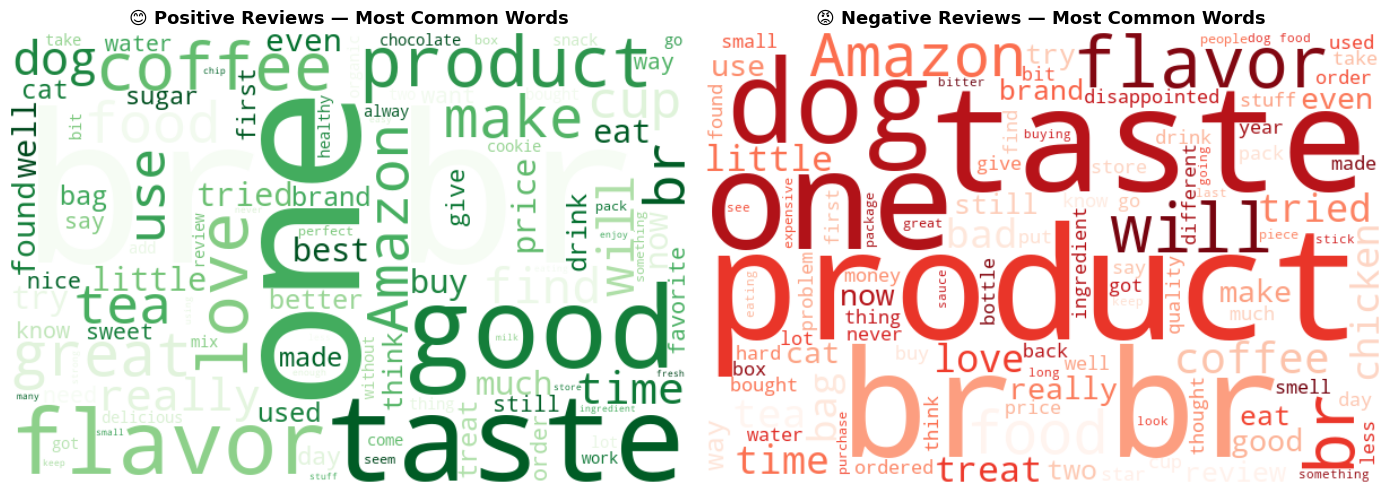

✅ Word cloud saved!


In [9]:
# ── Chart 4: Word Cloud ────────────────────────────────────
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive word cloud
positive_text = ' '.join(df_sample[df_sample['Sentiment']=='Positive']['Text'].astype(str))
wc_positive = WordCloud(width=600, height=400, 
                         background_color='white',
                         colormap='Greens',
                         max_words=100).generate(positive_text)
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].set_title('😊 Positive Reviews — Most Common Words', 
                   fontsize=13, fontweight='bold')
axes[0].axis('off')

# Negative word cloud
negative_text = ' '.join(df_sample[df_sample['Sentiment']=='Negative']['Text'].astype(str))
wc_negative = WordCloud(width=600, height=400,
                         background_color='white',
                         colormap='Reds',
                         max_words=100).generate(negative_text)
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].set_title('😡 Negative Reviews — Most Common Words',
                   fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()
print("✅ Word cloud saved!")